In [ ]:
import pandas as pd
df = pd.DataFrame({
    "palabras_del_poema_X": [45, 52, 47, 38, 40, 60, 35, 50, 42, 55, 48, 33, 58, 41, 50],
    "tiempo_en_minutos_Y": [2.46, 2.74, 2.48, 2.08, 2.15, 3.10, 1.90, 2.65, 2.30, 2.85, 2.50, 1.80, 3.00, 2.22, 2.60]})
df

,palabras_del_poema_X,tiempo_en_minutos_Y
0,45,2.46
1,52,2.74
2,47,2.48
3,38,2.08
4,40,2.15
5,60,3.10
6,35,1.90
7,50,2.65
8,42,2.30
9,55,2.85


**1. Varieble ($X$) Y ($Y$)**

La variable independiente ($X$) son las palabras del poema, porque es la que se utiliza para explicar o predecir el resultado. La variable dependiente ($Y$) es el tiempo en minutos, ya que depende de las palabras para medir el tiempo que tardan escribiendo.

In [ ]:
import pandas as pd
df = pd.DataFrame({
  "tiempo_en_minutos": (2.46, 2.74, 2.48, 2.08, 2.15, 3.10, 1.90, 2.65, 2.30, 2.85,
   2.50, 1.80, 3.00, 2.22, 2.60),
  "palabras_del_poema": (45, 52, 47, 38, 40, 60, 35, 50, 42, 55, 48, 33, 58, 41, 50)})

Y = df['tiempo_en_minutos']
X = df['palabras_del_poema']

**2. Diagrama de dispersión de datos**

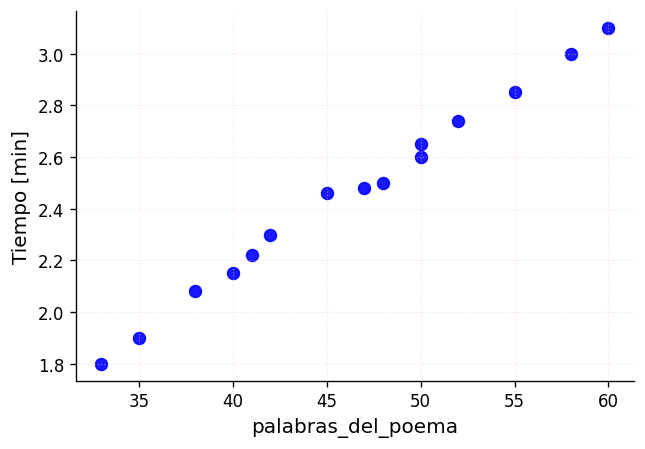

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

plt.scatter(
    X, Y,
    marker="o",       # forma de círculo
    color='blue',     # color de los puntos
    edgecolor='blue',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

plt.xlabel(
    'palabras_del_poema', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Tiempo [min]', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle=':',
    linewidth=0.7,
    alpha=0.5,
    color="pink"
)

plt.show()

El diagrama de dispersión muestra una tendencia positiva entre las variables; conforme aumenta el número de palabras del poema, también aumenta el tiempo empleado en escribirlo. Aunque existe cierta dispersión entre los puntos, se observa una relación ascendente.

**3. ¿Los datos soportan la suposición de linealidad?**

Sí, los datos respaldan la linealidad. La gráfica muestra una tendencia ascendente clara donde los puntos se alinean estrechamente de forma casi recta, lo que justifica el uso del modelo de regresión lineal.

**4. Coeficiente de correlación**

El coeficiente de correlación es $r = 0.9951$, lo que indica una correlación positiva muy fuerte entre el número de palabras del poema y el tiempo en minutos, ya que conforme aumenta la cantidad de palabras, también incrementa de manera directa y constante el tiempo requerido para escribirlo.

In [ ]:
from scipy.stats import pearsonr

Y = df['tiempo_en_minutos']
X = df['palabras_del_poema']

# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r:.4f}")
print(f"valor_p: {valor_p:.4e}")  # Usamos notación científica para ver el valor exacto con decimales

Coeficiente de correlación: 0.9972
valor_p: 5.0876e-16


**5. Calcule el coeficiente de determinación e interprete el resultado.**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import r2_score

df = pd.DataFrame({
  "tiempo_en_minutos": (2.46, 2.74, 2.48, 2.08, 2.15, 3.10, 1.90, 2.65, 2.30, 2.85,
   2.50, 1.80, 3.00, 2.22, 2.60),
  "palabras_del_poema": (45, 52, 47, 38, 40, 60, 35, 50, 42, 55, 48, 33, 58, 41, 50)
})

Y = df['tiempo_en_minutos']
X = df['palabras_del_poema']

x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

r2 = r2_score(Y, y_calculada)
print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  99.44%


El coeficiente de determinación es $R^2 = 99.44\%$, lo que significa que el $99.44\%$ de la variación del tiempo de escritura puede explicarse por el número de palabras del poema, mientras que el $0.56\%$ restante se debe a otros factores que no están considerados en el modelo.

**6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

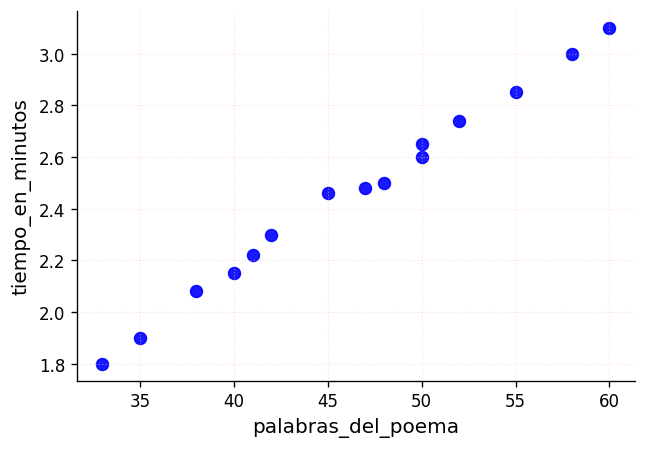

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

plt.scatter(
    X, Y,
    marker="o",       # forma de círculo
    color='blue',     # color de los puntos
    edgecolor='blue', # borde de los puntos
    alpha=0.9,        # transparencia
    s=50,             # tamaño de los puntos
)

plt.xlabel(
    'palabras_del_poema', # etiqueta del eje x
    fontsize=12           # tamaño de fuente
)

plt.ylabel(
    'tiempo_en_minutos',  # etiqueta del eje y
    fontsize=12           # tamaño de fuente
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

plt.grid(
    visible=True,
    linestyle=':',
    linewidth=0.7,
    alpha=0.5,
    color="pink"
)

plt.show()

In [ ]:
import statsmodels.api as sm

x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
Y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,0.276958
palabras_del_poema,0.047083


El modelo es:
$$\hat{Y} = 0.2770 + 0.0471X$$

donde $X$ es el número de palabras del poema y $\hat{Y}$ representa el tiempo estimado en minutos para escribirlo.

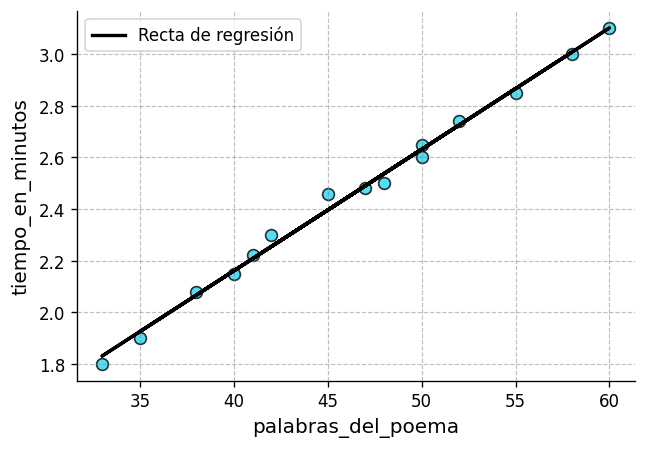

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

plt.scatter(
    X, Y,
    marker="o",       # forma de círculo
    color='#27D6F5',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
)

# Jennifer Hernandez Gallegos
# Gráfico de línea (Recta de regresión)
plt.plot(
    X, Y_calculada,
    color='black',   # color de la línea
    linewidth=2.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    label='Recta de regresión'
)

plt.xlabel(
    'palabras_del_poema', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'tiempo_en_minutos', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

plt.show()

**7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada** ($b_1$)

In [ ]:
modelo.conf_int(alpha=0.05)

,0,1
const,0.177509,0.376408
palabras_del_poema,0.044964,0.049202




$$0.0450 \le \beta_1 \le 0.0492$$

El intervalo de confianza al $95\%$ para la pendiente va de **$0.0450$** a **$0.0492$**. Como el valor $0$ no pertenece al intervalo, se concluye que la pendiente es estadísticamente significativa y existe evidencia de una relación lineal positiva entre el número de palabras del poema y el tiempo en minutos para escribirlo.

**8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [ ]:
residuales = modelo.resid

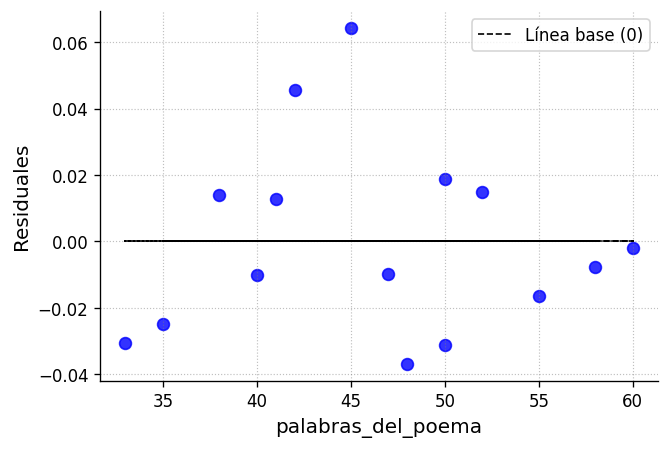

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

plt.scatter(
    X, residuales,
    marker="o",       # forma de círculo
    color='blue',     # color de los puntos
    edgecolor='blue', # borde de los puntos (se usa el mismo color para un borde sólido)
    alpha=0.8,        # transparencia
    s=50,             # tamaño de los puntos
)

plt.plot(
    X, y_calculada * 0,
    color='black',    # color de la línea
    linewidth=1.0,    # grosor de la línea
    linestyle='--',   # estilo de línea
    label='Línea base (0)'
)

# Etiquetas de los ejes
plt.xlabel(
    'palabras_del_poema', # etiqueta del eje x con tu variable del poema
    fontsize=12          # tamaño de fuente
)

plt.ylabel(
    'Residuales',        # etiqueta del eje y
    fontsize=12          # tamaño de fuente
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

plt.grid(
    visible=True,
    linestyle=':',
    linewidth=0.7,
    alpha=0.5,
    color="gray" # Cambié el color de la cuadrícula a gris para mejor contraste
)

plt.legend(
    loc='best',
    fontsize=10
)

plt.show()

El gráfico de residuales muestra que los puntos se distribuyen de manera aleatoria alrededor de cero, sin presentar patrones definidos, lo que indica que los supuestos del modelo de regresión se cumplen de forma razonable y que el ajuste lineal es adecuado para estos datos.

**9. Realice la prueba de Shapiro para los residuales y comente el resultado.**

Estadístico W = 0.9308531532029027
valor-p (Shapiro) = 0.28099679822408286


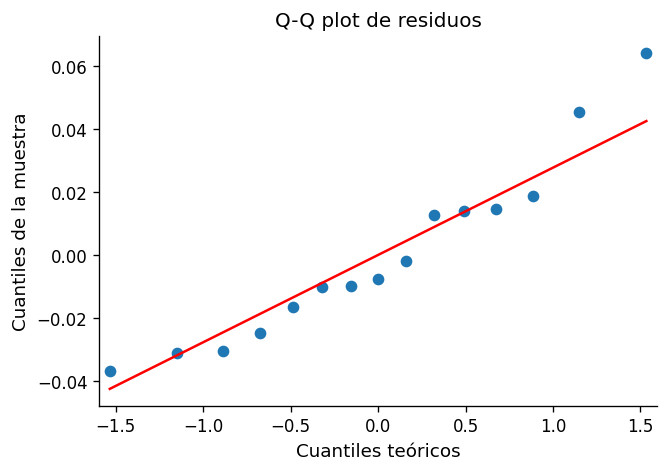

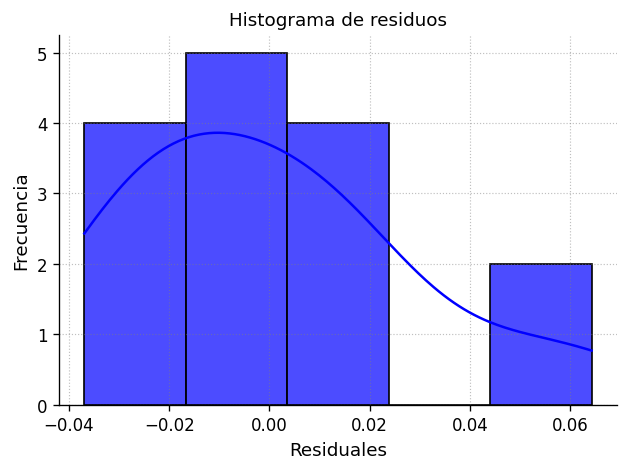

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

stat, valor_p_sh = shapiro(residuales)
print(f"Estadístico W = {stat}")
print(f"valor-p (Shapiro) = {valor_p_sh}")

plt.figure(figsize=(6, 4), dpi=120)
sm.qqplot(residuales, line='s', ax=plt.gca())
plt.title("Q-Q plot de residuos")
plt.xlabel("Cuantiles teóricos", fontsize=11)
plt.ylabel("Cuantiles de la muestra", fontsize=11)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

plt.figure(figsize=(6, 4), dpi=120)
sns.histplot(residuales, kde=True, color='blue', edgecolor='black', alpha=0.7)
plt.title("Histograma de residuos", fontsize=11)
plt.xlabel("Residuales", fontsize=11)
plt.ylabel("Frecuencia", fontsize=11)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.grid(visible=True, linestyle=':', linewidth=0.7, alpha=0.5, color="gray")
plt.show()

Para la prueba de Shapiro-Wilk:



*   H₀: Los residuales siguen una distribución normal.
*   H₁: Los residuales no siguen una distribución normal.



Como el valor-p = 0.2810 es mayor que 0.05, no se rechaza la hipótesis nula, concluyendo que los residuales siguen una distribución normal, por lo que se cumple de forma satisfactoria el supuesto de normalidad del modelo.

**10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [ ]:
from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm

# H0: No hay heterocedasticidad (la dispersión es homocedástica / constante)
# H1: Hay heterocedasticidad (la dispersión no es constante a lo largo de la recta)
# alpha = 0.05

_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.4406



Para la prueba de Breusch-Pagan:



*   H₀: Existe homocedasticidad (la varianza de los errores es constante).
*   H₁: Existe heterocedasticidad (la varianza de los errores no es constante).


Como el valor-p = 0.4406 es mayor que 0.05, no se rechaza la hipótesis nula, concluyendo que no existe evidencia de heterocedasticidad y que el modelo cumple de forma satisfactoria con el supuesto de homocedasticidad.

**11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [ ]:
import pandas as pd
import statsmodels.api as sm

df = pd.DataFrame({
    "palabras_del_poema": [45, 52, 47, 38, 40, 60, 35, 50, 42, 55, 48, 33, 58, 41, 50],
    "tiempo_en_minutos": [2.46, 2.74, 2.48, 2.08, 2.15, 3.10, 1.90, 2.65, 2.30, 2.85, 2.50, 1.80, 3.00, 2.22, 2.60]
})

X = df['palabras_del_poema']
Y = df['tiempo_en_minutos']

x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()

# Rango observado: Mínimo = 33, Máximo = 60
# Interpolación (dentro del rango, por ejemplo x = 45 y x = 50)
y_45 = modelo.predict([1, 45])
y_50 = modelo.predict([1, 50])

print(f"Interpolación y Extrapolación:\n")
print(f"Para x = 45, y = {y_45[0]: 0.4f}")
print(f"Para x = 50, y = {y_50[0]: 0.4f}")

y_70 = modelo.predict([1, 70])
print(f"Para x = 70,  y = {y_70[0]: 0.4f}")

Interpolación y Extrapolación:

Para x = 45, y =  2.3957
Para x = 50, y =  2.6311
Para x = 70,  y =  3.5728


In [ ]:
df["tiempo_predicho"] = y_calculada.round(2)

df

,palabras_del_poema,tiempo_en_minutos,tiempo_predicho
0,45,2.46,2.40
1,52,2.74,2.73
2,47,2.48,2.49
3,38,2.08,2.07
4,40,2.15,2.16
5,60,3.10,3.10
6,35,1.90,1.92
7,50,2.65,2.63
8,42,2.30,2.25
9,55,2.85,2.87


Se estima que para 45 palabras del poema el tiempo esperado para escribirlo es de 2.40 minutos, mientras que para 50 palabras el tiempo estimado es de 2.63 minutos. Como ambos valores se encuentran dentro del rango de los datos originales (33 a 60 palabras), estas predicciones corresponden a interpolaciones, por lo que pueden considerarse confiables.

**12. Realice una tabla ANOVA e interprete el resultado.**

In [ ]:
# Test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación lineal significativa)
# H1: beta_1 ≠ 0   (Sí hay correlación lineal significativa)

import statsmodels.api as sm
from statsmodels.formula.api import ols
modelo_lineal = ols(
    'tiempo_en_minutos ~ palabras_del_poema',
    data=df
).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
palabras_del_poema,1.0,2.050403,2.050403,2303.819351,5.087636e-16
Residual,13.0,0.011570,0.000890,NaN,NaN


Se obtuvo un valor $F = 2303.8194$ y un valor-p = $5.0876 \times 10^{-16}$ (el cual es sumamente menor que 0.05). Por ello, se rechaza la hipótesis nula y se concluye que existe una relación lineal significativa entre el número de palabras del poema y el tiempo en minutos, por lo que el modelo de regresión es adecuado para explicar los datos.